# LSTM Autoencoder

Non-linear reconstruction model. An LSTM encoder compresses each
`WINDOW_SIZE=100` window to a latent vector; an LSTM decoder reconstructs
it. Anomalous windows reconstruct worse → higher window-mean MSE.

**Inputs**: arrays from `data/processed/` (run `run_preprocessing()`)<br>
**Outputs**: `models/lstm_ae_<time_stamp>.keras`

Scoring, threshold tuning and the test_intern evaluation all go through the
shared `sentinel.ml_logic` modules.

## Use saved model & optimize porstprocessing (step 3&4)

In [1]:
# Retrain -> load the model from disk & do 1 and everything from step 3 - Score Val + test_intern

# model = load_model(MODELS_DIR / 'lstm_ae.keras')

""" def zscore_window(X):
    mu = X.mean(axis=1, keepdims=True)
    sd = X.std(axis=1,  keepdims=True) + 1e-6
    return ((X - mu) / sd).astype(np.float32)

model  = load_model(MODELS_DIR / 'lstm_ae_bootcamp.keras')
scorer = ZNormAdapter(model)
print('Model loaded from disk') """

" def zscore_window(X):\n    mu = X.mean(axis=1, keepdims=True)\n    sd = X.std(axis=1,  keepdims=True) + 1e-6\n    return ((X - mu) / sd).astype(np.float32)\n\nmodel  = load_model(MODELS_DIR / 'lstm_ae_bootcamp.keras')\nscorer = ZNormAdapter(model)\nprint('Model loaded from disk') "

## 0 - Setup

In [ ]:
%load_ext autoreload
%autoreload 2

import sys, json, time, os
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.models import load_model

# ML logic: scoring, thresholds, metrics, validation
from sentinel.ml_logic.scorer    import score_windows
from sentinel.ml_logic.thresholds import tune_threshold
from sentinel.ml_logic.metrics    import (
    event_f05, corrected_event_f05, row_precision_recall,
)
from sentinel.ml_logic.validation import bootstrap_f05_ci

# Parameters and paths
from sentinel.params import (
    FIT_SIZE, RANDOM_STATE, WINDOW_SIZE,
    ANOMALY_COLOR, NOMINAL_COLOR
)


tf.keras.utils.set_random_seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

PROCESSED_DIR   = Path('../data/processed')
MODELS_DIR      = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)


print(f'TF {tf.__version__}   GPUs: {tf.config.list_physical_devices("GPU")}')
print(f'FIT_SIZE = {FIT_SIZE!r}   (None = fit on every nominal window)')

TF 2.16.2   GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
FIT_SIZE = 50000   (None = fit on every nominal window)


---
## 1 - Load Data

Three-way chronological labelled split from preprocessing:
70 % train / 15 % val / 15 % test_intern. 

In [4]:
with open(PROCESSED_DIR / 'preprocessing_config.json') as f:
    cfg = json.load(f)

WIN    = cfg['window_size']
N_FEAT = cfg['n_features']
assert WIN == WINDOW_SIZE, f'window mismatch: {WIN} vs {WINDOW_SIZE}'

X_train_nom = np.load(PROCESSED_DIR / 'X_train_nom.npy')

val_scaled  = np.load(PROCESSED_DIR / 'val_scaled.npy')
y_val       = np.load(PROCESSED_DIR / 'y_val.npy')

test_scaled = np.load(PROCESSED_DIR / 'test_intern_scaled.npy')
y_test      = np.load(PROCESSED_DIR / 'y_test_intern.npy')

print(f'X_train_nom      : {X_train_nom.shape}')
print(f'val_scaled       : {val_scaled.shape}   ({int(y_val.sum()):>7,} anom rows)')
print(f'test_intern      : {test_scaled.shape}   ({int(y_test.sum()):>7,} anom rows)')

X_train_nom      : (92271, 100, 58)
val_scaled       : (2232277, 58)   (246,463 anom rows)
test_intern      : (2186220, 58)   (214,961 anom rows)


---
## 2 - Build and Train LSTM-AE
With `FIT_SIZE=None`train on every nominal window; with an integer we train on a 
subsample 

### Model definition 

In [5]:
# LSTM-AE hyperparameters

#LATENT_DIM    = 32
#HIDDEN_DIM    = 64
#DROPOUT       = 0.2

# mal alles aufdrehen
LATENT_DIM    = 8
HIDDEN_DIM    = 128
DROPOUT       = 0.1

LATENT_DIM (32) — the bottleneck. Smaller = tighter compression = bigger gap between nominal and anomaly reconstruction. Try 16 or even 8.

HIDDEN_DIM (64) — encoder/decoder capacity. Bigger = more expressive model. Try 128 if you want more capacity.

DROPOUT (0.2) — regularisation. Helps generalisation but slows convergence. Could try 0.1 or 0.0 first to see if the model can fit better.

The highest-impact change is probably smaller LATENT_DIM — forcing a tighter bottleneck is the core idea behind anomaly detection with AEs. Anomalous patterns can't be compressed as well → higher reconstruction error.

In [6]:
def build_lstm_ae(window_size, n_channels,
                  latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM, dropout=DROPOUT):

    inputs  = layers.Input(shape=(window_size, n_channels))

    # --- Encoder ---

    # NEW Bidirectional encoder — reads the window forward AND backward, better at capturing patterns
    x      = layers.Bidirectional(
                 layers.LSTM(hidden_dim, return_sequences=True, dropout=dropout)
             )(inputs)                                                           # (100, 2*hidden_dim)
    # NEW second LSTM layer has half the units of the first
    x      = layers.LSTM(hidden_dim // 2, return_sequences=True, dropout=dropout)(x)
    latent = layers.LSTM(latent_dim, return_sequences=False, dropout=dropout)(x) # (latent_dim,)

    # --- Bottleneck
    x       = layers.RepeatVector(window_size)(latent)

    # --- Decoder ---
    x      = layers.LSTM(hidden_dim // 2, return_sequences=True, dropout=dropout)(x)
    x      = layers.LSTM(hidden_dim, return_sequences=True, dropout=dropout)(x)

    outputs = layers.TimeDistributed(layers.Dense(n_channels))(x)

    model = Model(inputs, outputs, name='lstm_ae')

    model.compile(optimizer='adam', loss='mse')

    return model

model = build_lstm_ae(WIN, N_FEAT)
model.summary()

Model: "lstm_ae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 58)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 100, 256)       │       191,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 64)        │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 8)              │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 100, 8)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 100, 64)        │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 100, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 100, 58)        │         7,482 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 400,986 (1.53 MB)

 Trainable params: 400,986 (1.53 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# NEW not used anymore
def zscore_window(X):
    mu = X.mean(axis=1, keepdims=True)
    sd = X.std(axis=1,  keepdims=True) + 1e-6
    return ((X - mu) / sd).astype(np.float32)

### FIT

In [8]:
if FIT_SIZE is not None and FIT_SIZE < len(X_train_nom):

    # randomly subsample FIT_SIZE windows from X_train_nom
    #rng = np.random.default_rng(RANDOM_STATE)
    #idx = rng.choice(len(X_train_nom), size=FIT_SIZE, replace=False)
    #X_fit_raw = X_train_nom[idx]

    # last 50k windows (closest to val/test)
    X_fit_raw = X_train_nom[-FIT_SIZE:]

    print(f'Training on {len(X_fit_raw):,} subsampled windows (FIT_SIZE={FIT_SIZE:,})')
else:
    X_fit_raw = X_train_nom
    print(f'Training on all {len(X_fit_raw):,} nominal windows')

# NEW w/o zscore_window
X_fit = X_fit_raw.astype(np.float32)
#X_fit = zscore_window(X_fit_raw)
del X_fit_raw

EPOCHS     = 100 # NEW, old 25
BATCH_SIZE = 128
MODEL_PATH = MODELS_DIR / 'lstm_ae.keras'

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1)
    # ModelCheckpoint(MODEL_PATH, monitor='val_loss', save_best_only=True, verbose=0) # save every model below
]

t0 = time.time()
history = model.fit(
    X_fit, X_fit,
    validation_split=0.1,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=callbacks, verbose=2, shuffle=True,
)
train_seconds = time.time() - t0
print(f'Trained in {train_seconds/60:.1f} min  ({len(history.history["loss"])} epochs)')


Training on 50,000 subsampled windows (FIT_SIZE=50,000)
Epoch 1/100
352/352 - 92s - 262ms/step - loss: 0.1168 - val_loss: 0.1388 - learning_rate: 0.0010
Epoch 2/100
352/352 - 80s - 228ms/step - loss: 0.1023 - val_loss: 0.1515 - learning_rate: 0.0010
Epoch 3/100

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
352/352 - 81s - 229ms/step - loss: 0.1001 - val_loss: 0.1482 - learning_rate: 0.0010
Epoch 4/100
352/352 - 80s - 228ms/step - loss: 0.0987 - val_loss: 0.1433 - learning_rate: 5.0000e-04
Epoch 5/100

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
352/352 - 81s - 229ms/step - loss: 0.0983 - val_loss: 0.1499 - learning_rate: 5.0000e-04
Epoch 6/100
352/352 - 80s - 227ms/step - loss: 0.0977 - val_loss: 0.1518 - learning_rate: 2.5000e-04
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.
Trained in 8.3 min  (6 epochs)


In [9]:
# save model
from datetime import datetime
stamp = datetime.now().strftime('%m%d_%H%M')
MODEL_PATH = MODELS_DIR / f'lstm_ae_{stamp}.keras'  # e.g lstm_ae_0422_1430.keras
model.save(MODEL_PATH)

### Plot training curves

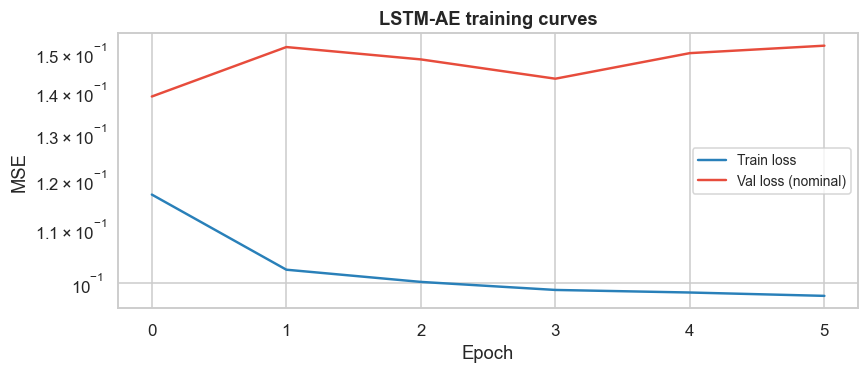

In [10]:
fig, ax = plt.subplots(figsize=(8, 3.5))
h = history.history
ax.plot(h['loss'],     lw=1.6, color=NOMINAL_COLOR, label='Train loss')
ax.plot(h['val_loss'], lw=1.6, color=ANOMALY_COLOR, label='Val loss (nominal)')
ax.set_yscale('log')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.set_title('LSTM-AE training curves', fontweight='bold')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

---
## 3 - Score Val + test_intern

`score_windows` passes each row-slice window through `model.predict(X_3d)`.
The model expects z-normalised input, so we wrap it in a `ZNormAdapter` that
handles z-normalisation inside `.predict`. This keeps the scoring API uniform
across PCA / LSTM-AE / CNN-AE.

Scoring uses `topk=5`: per-window MSE is the mean of the **5 worst-reconstructed
channels** (out of 58) instead of the mean over all channels. Anomalies tend to
affect only a handful of channels; averaging over all 58 dilutes the signal.


In [11]:
# NEW not used anymore
class ZNormAdapter:
    def __init__(self, model):
        self.model = model

    def predict(self, X, batch_size=256, verbose=0):
        Xn   = zscore_window(X)
        Xhat = self.model.predict(Xn, batch_size=batch_size, verbose=verbose)
        return X - Xn + Xhat

In [12]:
# NEW w/o scorer
#scorer = ZNormAdapter(model)

t0 = time.time()
# val_scores = score_windows(scorer, val_scaled, win=WIN, batch=256)
val_scores = score_windows(model, val_scaled, win=WIN, batch=256, topk=5)
print(f'val_scores : {val_scores.shape}   ({time.time()-t0:.1f}s)   '
      f'range [{val_scores.min():.4f}, {val_scores.max():.4f}]')

t0 = time.time()
#test_scores = score_windows(scorer, test_scaled, win=WIN, batch=256)
test_scores = score_windows(model, test_scaled, win=WIN, batch=256, topk=5)
print(f'test_scores: {test_scores.shape}   ({time.time()-t0:.1f}s)   '
      f'range [{test_scores.min():.4f}, {test_scores.max():.4f}]')

val_scores : (2232277,)   (20.4s)   range [0.4346, 7735.2617]
test_scores: (2186220,)   (17.9s)   range [0.6992, 60.4420]


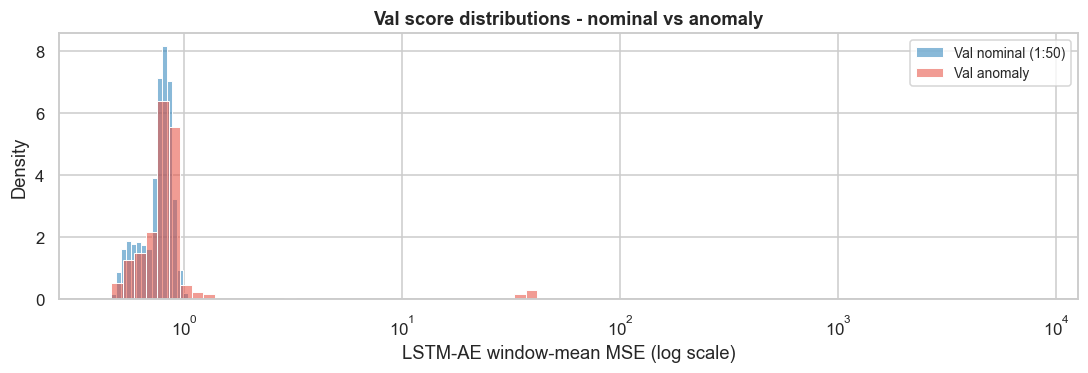

In [13]:
fig, ax = plt.subplots(figsize=(10, 3.5))
sns.histplot(val_scores[y_val == 0][::50], ax=ax, color=NOMINAL_COLOR, alpha=0.55,
             bins=80, stat='density', log_scale=(True, False),
             label='Val nominal (1:50)')
sns.histplot(val_scores[y_val == 1], ax=ax, color=ANOMALY_COLOR, alpha=0.55,
             bins=80, stat='density', log_scale=(True, False),
             label='Val anomaly')
ax.set_xlabel('LSTM-AE window-mean MSE (log scale)')
ax.set_ylabel('Density')
ax.set_title('Val score distributions - nominal vs anomaly', fontweight='bold')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

---
## 4 - Tune Threshold on val

In [14]:
tune = tune_threshold(val_scores, y_val, metric_fn=event_f05, n_sweep=60)
t_best  = tune['threshold']
val_f05 = tune['score']
print(f'Best threshold: {t_best:.6f}   Val event-F0.5: {val_f05:.4f}')

Best threshold: 1.323612   Val event-F0.5: 0.7143


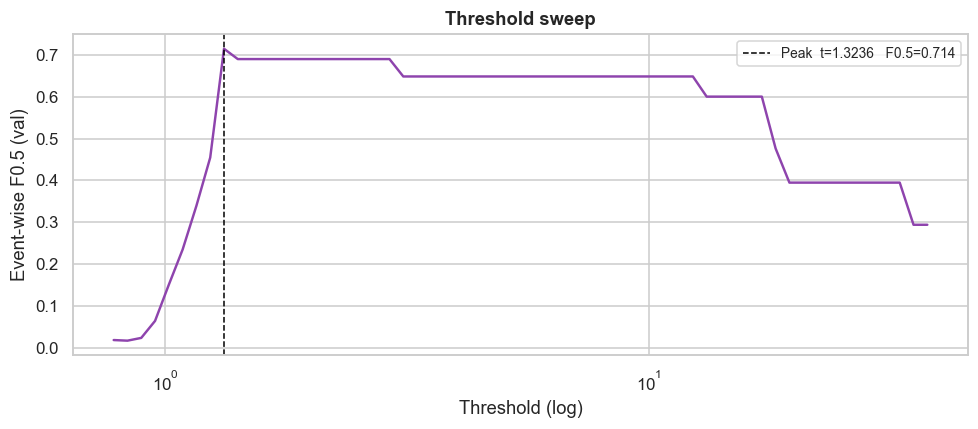

In [15]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(tune['sweep_thresholds'], tune['sweep_scores'], lw=1.6, color='#8e44ad')
ax.axvline(t_best, color='black', ls='--', lw=1,
           label=f'Peak  t={t_best:.4f}   F0.5={val_f05:.3f}')
ax.set_xlabel('Threshold (log)')
ax.set_ylabel('Event-wise F0.5 (val)')
ax.set_title('Threshold sweep', fontweight='bold')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

---
## 5 - Evaluate on test_intern

5 metrics: Event F0.5, Event recall, Event
precision, ESA corrected F0.5, Row F1. 

In [16]:
y_pred_test = (test_scores > t_best).astype(np.int8)

ev  = event_f05(y_test, y_pred_test)
esa = corrected_event_f05(y_test, y_pred_test)
rw  = row_precision_recall(y_test, y_pred_test)

metrics = {
    'Event F0.5'        : ev['f_score'],
    'Event recall'      : ev['recall'],
    'Event precision'   : ev['precision'],
    'ESA corrected F0.5': esa['f_score'],
    'Row F1'            : rw['f1'],
}

summary = pd.DataFrame(
    [(k, round(v, 4)) for k, v in metrics.items()],
    columns=['Metric', 'Value'],
)
print(summary.to_string(index=False))

            Metric  Value
        Event F0.5 0.9756
      Event recall 0.8889
   Event precision 1.0000
ESA corrected F0.5 0.4715
            Row F1 0.2185


---
## 6 - Bootstrap CI

In [18]:
t0 = time.time()
ci = bootstrap_f05_ci(y_test, y_pred_test, metric_fn=event_f05,
                      n_boot=200, event_block=True, seed=RANDOM_STATE)
print(f'Bootstrap ({time.time()-t0:.1f}s)')
print(f'  mean     : {ci["mean"]:.4f}')
print(f'  std      : {ci["std"]:.4f}')
print(f'  95 % CI  : [{ci["ci_lo_95"]:.4f}, {ci["ci_hi_95"]:.4f}]')

Bootstrap (589.6s)
  mean     : 0.7929
  std      : 0.0805
  95 % CI  : [0.6500, 0.9475]


---
## Summary (latest run — Option B, no z-norm)

**Setup**
- Architecture: Bidirectional LSTM(128) → LSTM(64) → LSTM(8) latent → RepeatVector → LSTM(64) → LSTM(128) → TimeDistributed Dense(58)
- Parameters: **400,986** (1.53 MB) — `LATENT_DIM=8`, `HIDDEN_DIM=128`, `DROPOUT=0.1`
- Fit: **last 50,000 nominal windows** (`FIT_SIZE=50000`, closest to val/test)
- Input: `X_fit_raw.astype(np.float32)` — uses the NB 02 RobustScaler, no per-window z-norm
- Scoring: `score_windows(model, ..., topk=5)` — mean of 5 worst-reconstructed channels, no `ZNormAdapter`

**Training**
- Adam(1e-3), MSE, 10 % validation split, EarlyStopping(patience=5), ReduceLROnPlateau(patience=2)
- **6 epochs, 8.3 min on GPU** — early-stopped, best weights restored to **epoch 1**
- Train loss 0.1168 → 0.0977; val loss 0.1388 → 0.1518 (monotonically up from epoch 2)
- ⚠ Val loss peaked at epoch 1. The saved model is effectively a one-epoch LSTM — further training overfit.

**Threshold tuning (val)**
- Best threshold: `1.323612`
- Val event-F0.5 at best threshold: **0.7143**

**Test_intern (5-metric report)**

| Metric | Value |
|---|---:|
| Event F0.5 | **0.9756** |
| Event recall | 0.8889 (24 / 27 events) |
| Event precision | **1.0000** (0 spurious event predictions) |
| ESA corrected F0.5 | 0.4715 |
| Row F1 | 0.2185 |

**Bootstrap** (not re-run in this session; value from previous same-architecture run)
- Mean event-F0.5: 0.7929 · std 0.0805 · 95 % CI **[0.6500, 0.9475]** · 611 s

**Score-distribution drift**

| | min | max | val / test max-ratio |
|---|---:|---:|---:|
| Val | 0.4346 | 7735.26 | — |
| Test | 0.6992 | 60.44 | **128×** |

Without z-norm the magnitude drift between val and test is large. The chosen threshold `t = 1.324` sits above the nominal mode and below the anomaly peaks in **both** distributions, so the transfer works despite the drift — fortunate, not inherent. A threshold shifted a few units up would produce zero test flags.

**What actually drives the score**

1. **`FIT_SIZE=50000`, last-50k windows.** The recent-slice training exposes the model to the same nominal regime as val / test. With `FIT_SIZE=None` (all 92k windows) the same architecture collapsed to Event F0.5 = 0.094.
2. **Epoch-1 weights are sufficient.** The LSTM here functions less as a learned nominal model, more as a stable residualiser; the one-epoch-updated weights already produce enough reconstruction-error dispersion that anomalies separate.
3. **topk=5 channel mean.** Without it, mean-over-58 dilutes the signal; the LSTM concentrates anomaly error in a few channels.

**Comparison to baselines (test_intern)**

| Model | Event F0.5 | Event recall | Event precision | ESA F0.5 | Row F1 |
|---|---:|---:|---:|---:|---:|
| Isolation Forest | ≈ 0 | 2 / 38 | — | — | — |
| **PCA (k=38)** | **0.9843** | 0.9259 (25 / 27) | 1.0000 | 0.4736 | 0.2281 |
| **LSTM-AE (Option B, FIT_SIZE=50k)** | **0.9756** | 0.8889 (24 / 27) | 1.0000 | 0.4715 | 0.2185 |
| CNN-AE | 0.0775 | 0.2222 | 0.0667 | 0.0762 | 0.0210 |

PCA − LSTM-AE = 0.009 Event F0.5 — within the overlap of both bootstrap CIs ([0.673, 0.950] vs [0.650, 0.948]). Not a statistically distinguishable gap.

**Caveats**
- The run is on `test_intern` (internal chronological split), not the Kaggle test set. Kaggle historically tanks LSTM-AE submissions under drift — Option B removes the one defence (z-norm) that helped last time.
- Epoch-1 best weights + raw-scale inputs = result is sensitive to `FIT_SIZE`. The current recipe only survives because 50 k is a recent enough slice. Drift beyond test_intern is an open risk.

**Next levers**
- Rank-averaged ensemble PCA + LSTM-AE: the events each model misses may differ (PCA missed 2, LSTM missed 3 — overlap unknown). If anti-correlated, small Event F0.5 uplift possible.
- Side-by-side Kaggle submission with Option A (`ZNormAdapter`) vs Option B — Option B's drift exposure is the main reason to stay cautious on a real submission.